In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import time
import matplotlib
import sys
import pandas as pd

sys.path.append('../')
from carpet_reconstruction import GetCarpetSignal, VEM, get_rho, NKG, num_sort, get_xy_fits

from matplotlib.backends.backend_pdf import PdfPages
from skimage.feature import peak_local_max
from scipy.optimize import minimize
from scipy.optimize import curve_fit
from scipy.special import gamma

In [2]:
# matplotlib.use('pdf') #Чтобы не убить оперативку
plt.rcParams['figure.dpi'] = 400
# plt.style.use('fivethirtyeight')

In [3]:
path = '../Data/photon_data/'

filenames = [path + filename for filename in os.listdir(path)]
filenames.sort(key=num_sort)

In [4]:
theta_true = []

for filename in filenames:

    print(filename)

    file = uproot.open(filename)
    names = np.array(file.keys())
    cover_hists = names[len(names) // 3::2]

    for i in range(len(cover_hists)):
        theta_true.append(float(cover_hists[i].split('_')[1]))

../Data/photon_data/output0.root
../Data/photon_data/output1.root
../Data/photon_data/output2.root
../Data/photon_data/output3.root
../Data/photon_data/output4.root
../Data/photon_data/output5.root
../Data/photon_data/output6.root
../Data/photon_data/output7.root
../Data/photon_data/output8.root
../Data/photon_data/output9.root
../Data/photon_data/output10.root
../Data/photon_data/output11.root
../Data/photon_data/output12.root
../Data/photon_data/output13.root
../Data/photon_data/output14.root
../Data/photon_data/output15.root
../Data/photon_data/output16.root
../Data/photon_data/output17.root
../Data/photon_data/output18.root
../Data/photon_data/output19.root
../Data/photon_data/output20.root
../Data/photon_data/output21.root
../Data/photon_data/output22.root
../Data/photon_data/output23.root
../Data/photon_data/output24.root
../Data/photon_data/output25.root
../Data/photon_data/output26.root
../Data/photon_data/output27.root
../Data/photon_data/output28.root


(array([2567., 2627., 2633., 2719., 2873., 2756., 2939., 2957., 3000.,
        3129.]),
 array([0.76604781, 0.78944251, 0.81283721, 0.83623191, 0.85962661,
        0.88302131, 0.90641601, 0.92981071, 0.95320541, 0.97660011,
        0.99999481]),
 <BarContainer object of 10 artists>)

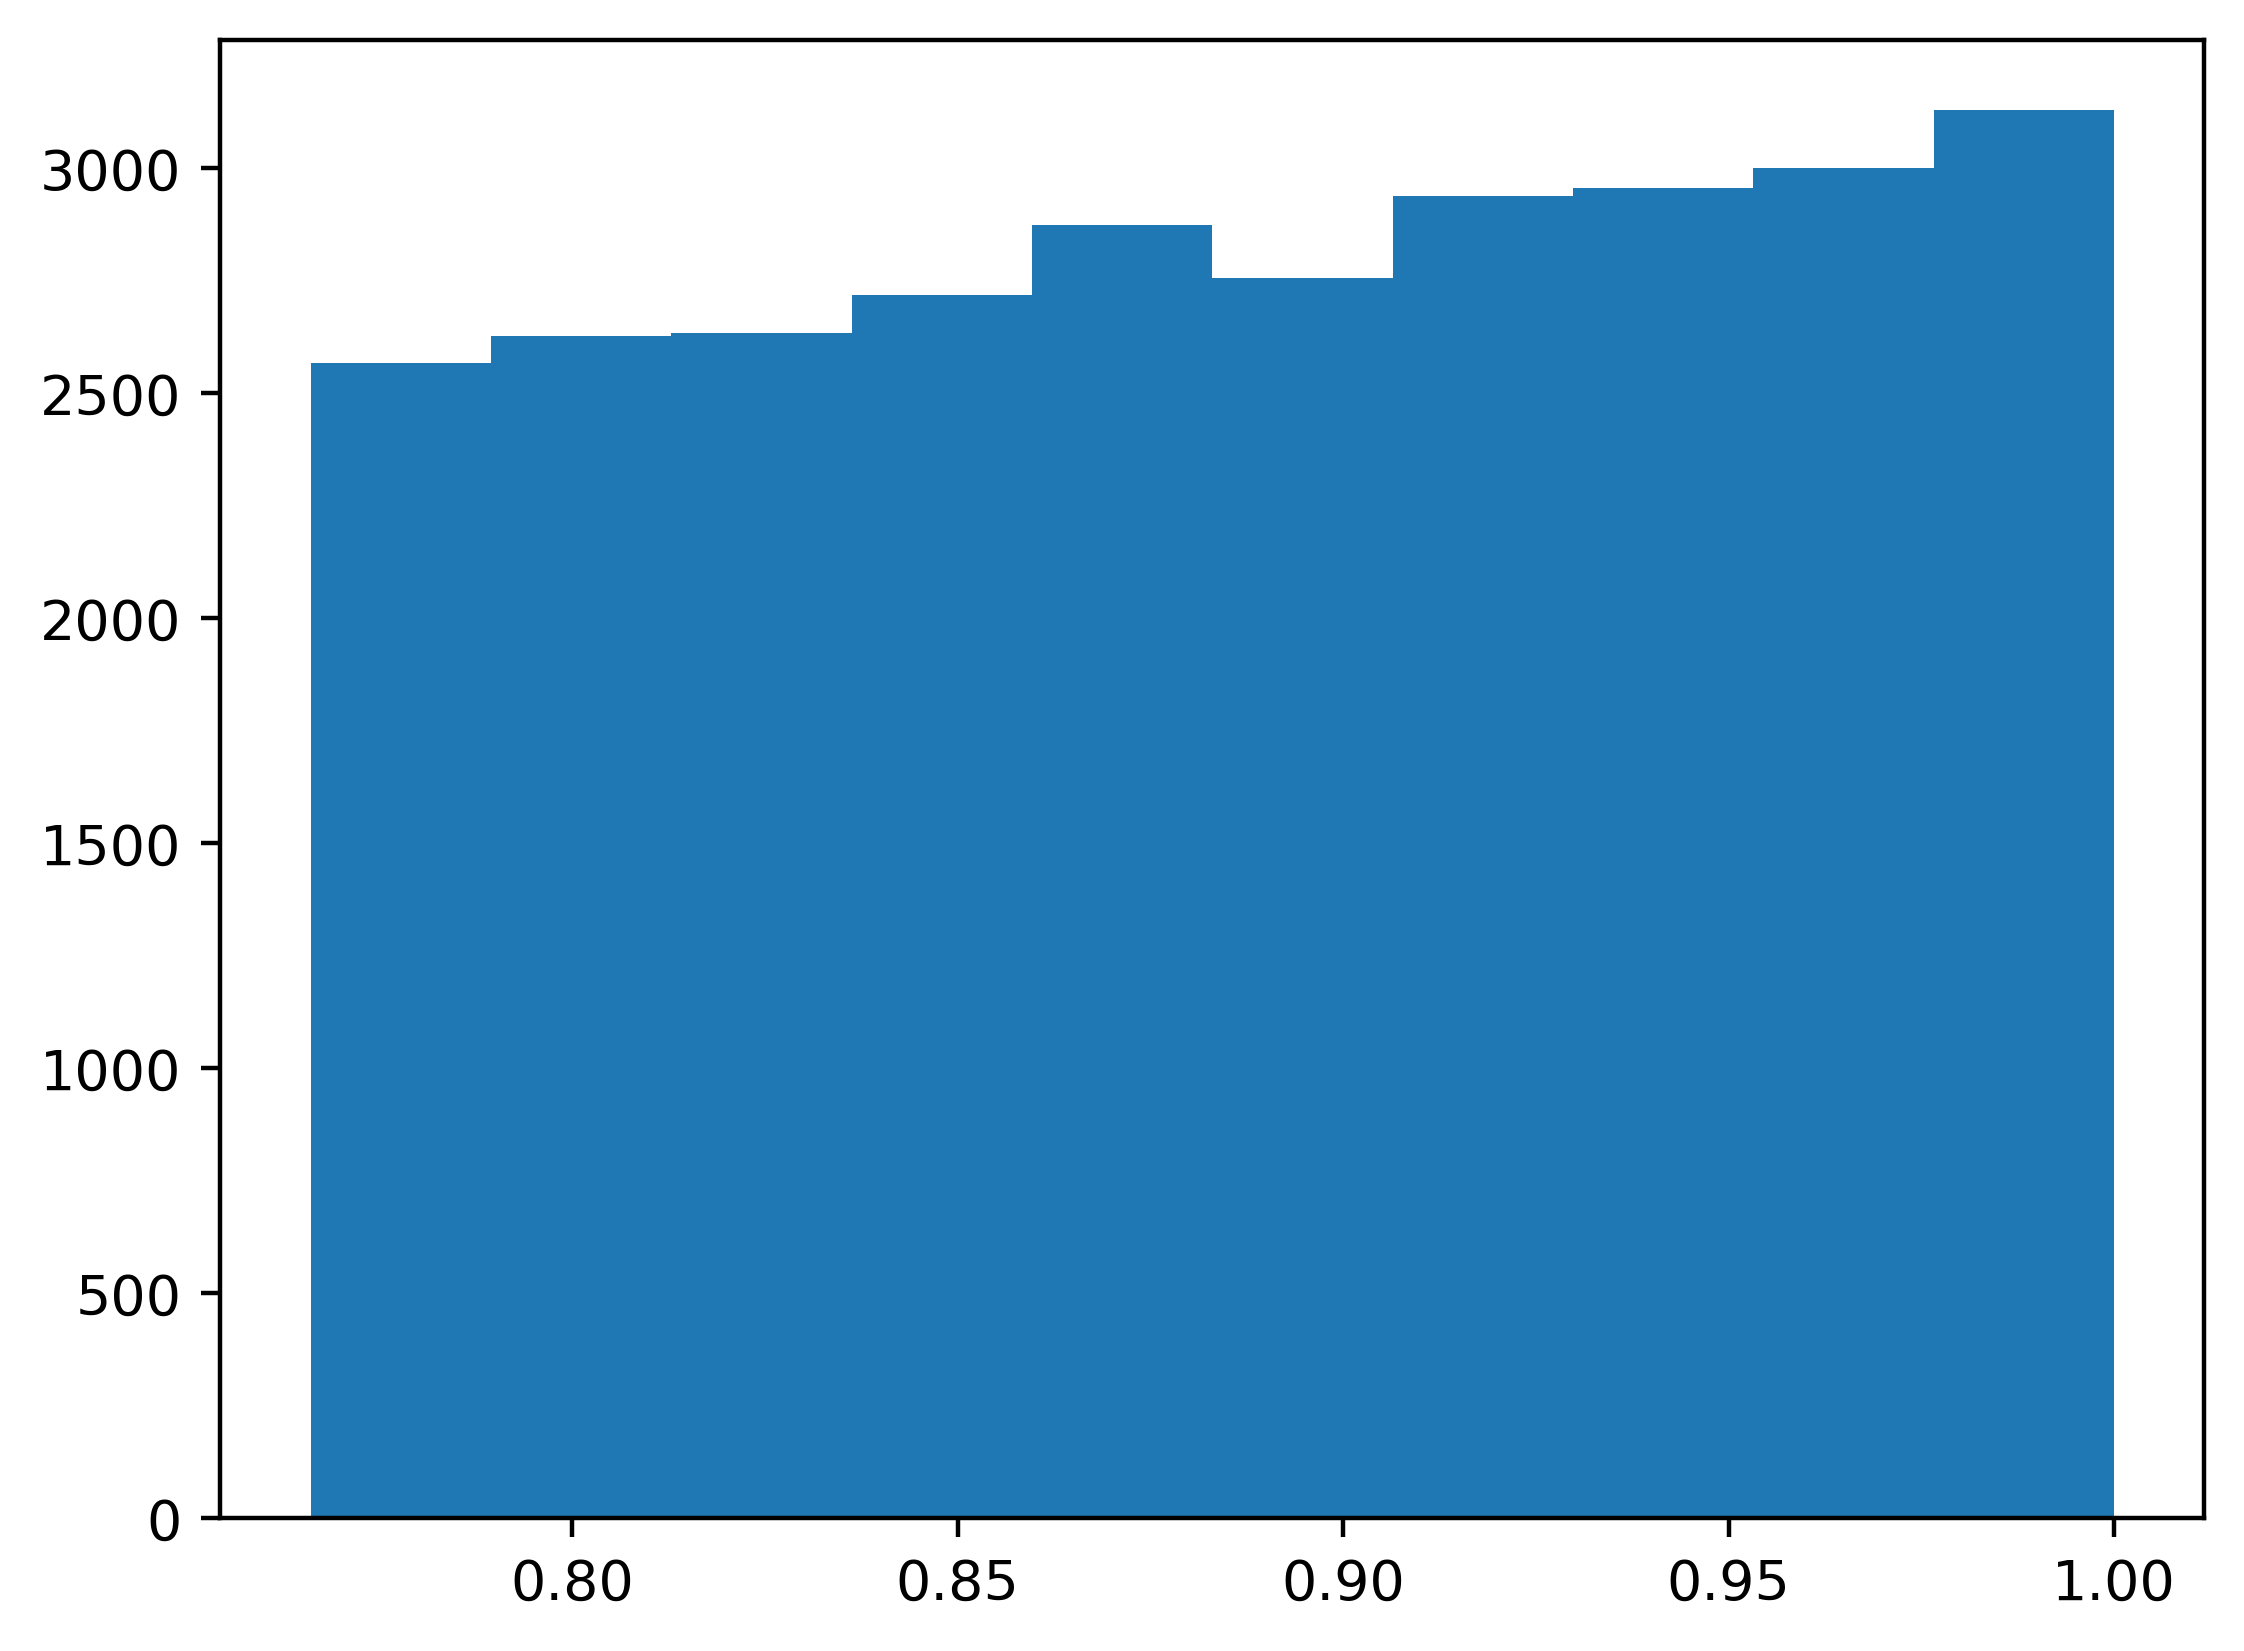

In [5]:
plt.hist(np.cos(np.radians(theta_true)))
#plt.hist(theta_true)

In [29]:
Ne = []
Ne_true = []
theta = []
theta_true = []
E = []

for filename in filenames:

    print(filename)
    
    file = uproot.open(filename)

    names = np.array(file.keys())
    times = names[:len(names) // 3]
    cover_hists = names[len(names) // 3::2]

    cover_signals = np.zeros((len(cover_hists), 20, 20))

    for i, hist in enumerate(cover_hists):
        cov_hist = np.copy(np.flip(file[hist].values().T, 0))
        #cover_signals[i] = VEM(GetCarpetSignal(cov_hist))
        cover_signals[i] = GetCarpetSignal(cov_hist)
    
    time_array = np.zeros((len(times), 4))
    
    for i, t in enumerate(times):
        time_array[i] = file[t]['t_ns'].array(library='np')[1:5]

    for i in range(len(cover_signals)):

        sig = cover_signals[i]
        times = time_array[i]
        

        #if ((np.all(times)) and (np.count_nonzero(sig) > 50)):
        if ((np.all(times)) and (np.sum(sig) > 15)):

            #r, rho, theta_local = get_rho(sig, times)
        
            try:
                #popt, pcov = curve_fit(NKG, r, rho, bounds=([0.4, 10**4], [1.8, 10**8]))
                #axs[0].plot(r, NKG(r, *popt), '-ro', linewidth = 2, markersize=3, label='NKG fit: s=%5.3f, Ne=%5.3f' % tuple(popt))
                #Ne_local = popt[1]
                #Ne_true_local = float(cover_hists[i].split('_')[-1].split(';')[0])
                #theta_true_local = float(cover_hists[i].split('_')[1])
                E_local = float(cover_hists[i].split('_')[0])

                #Ne.append(Ne_local)
                #Ne_true.append(Ne_true_local)
                #theta.append(theta_local)
                #theta_true.append(theta_true_local)
                E.append(E_local)
        
            except RuntimeError:
                ...
                # print('Unable to fit')
            except TypeError:
                ...
                # print('Unable to fit again')
            except ValueError:
                ...
                # print('Data empty')

            
print('fin')

../Data/photon_data/output0.root
../Data/photon_data/output1.root
../Data/photon_data/output2.root
../Data/photon_data/output3.root
../Data/photon_data/output4.root
../Data/photon_data/output5.root
../Data/photon_data/output6.root
../Data/photon_data/output7.root
../Data/photon_data/output8.root
../Data/photon_data/output9.root
../Data/photon_data/output10.root
../Data/photon_data/output11.root
../Data/photon_data/output12.root
../Data/photon_data/output13.root
../Data/photon_data/output14.root
../Data/photon_data/output15.root
../Data/photon_data/output16.root
../Data/photon_data/output17.root
../Data/photon_data/output18.root
../Data/photon_data/output19.root
../Data/photon_data/output20.root
../Data/photon_data/output21.root
../Data/photon_data/output22.root
../Data/photon_data/output23.root
../Data/photon_data/output24.root
../Data/photon_data/output25.root
../Data/photon_data/output26.root
../Data/photon_data/output27.root
../Data/photon_data/output28.root
fin


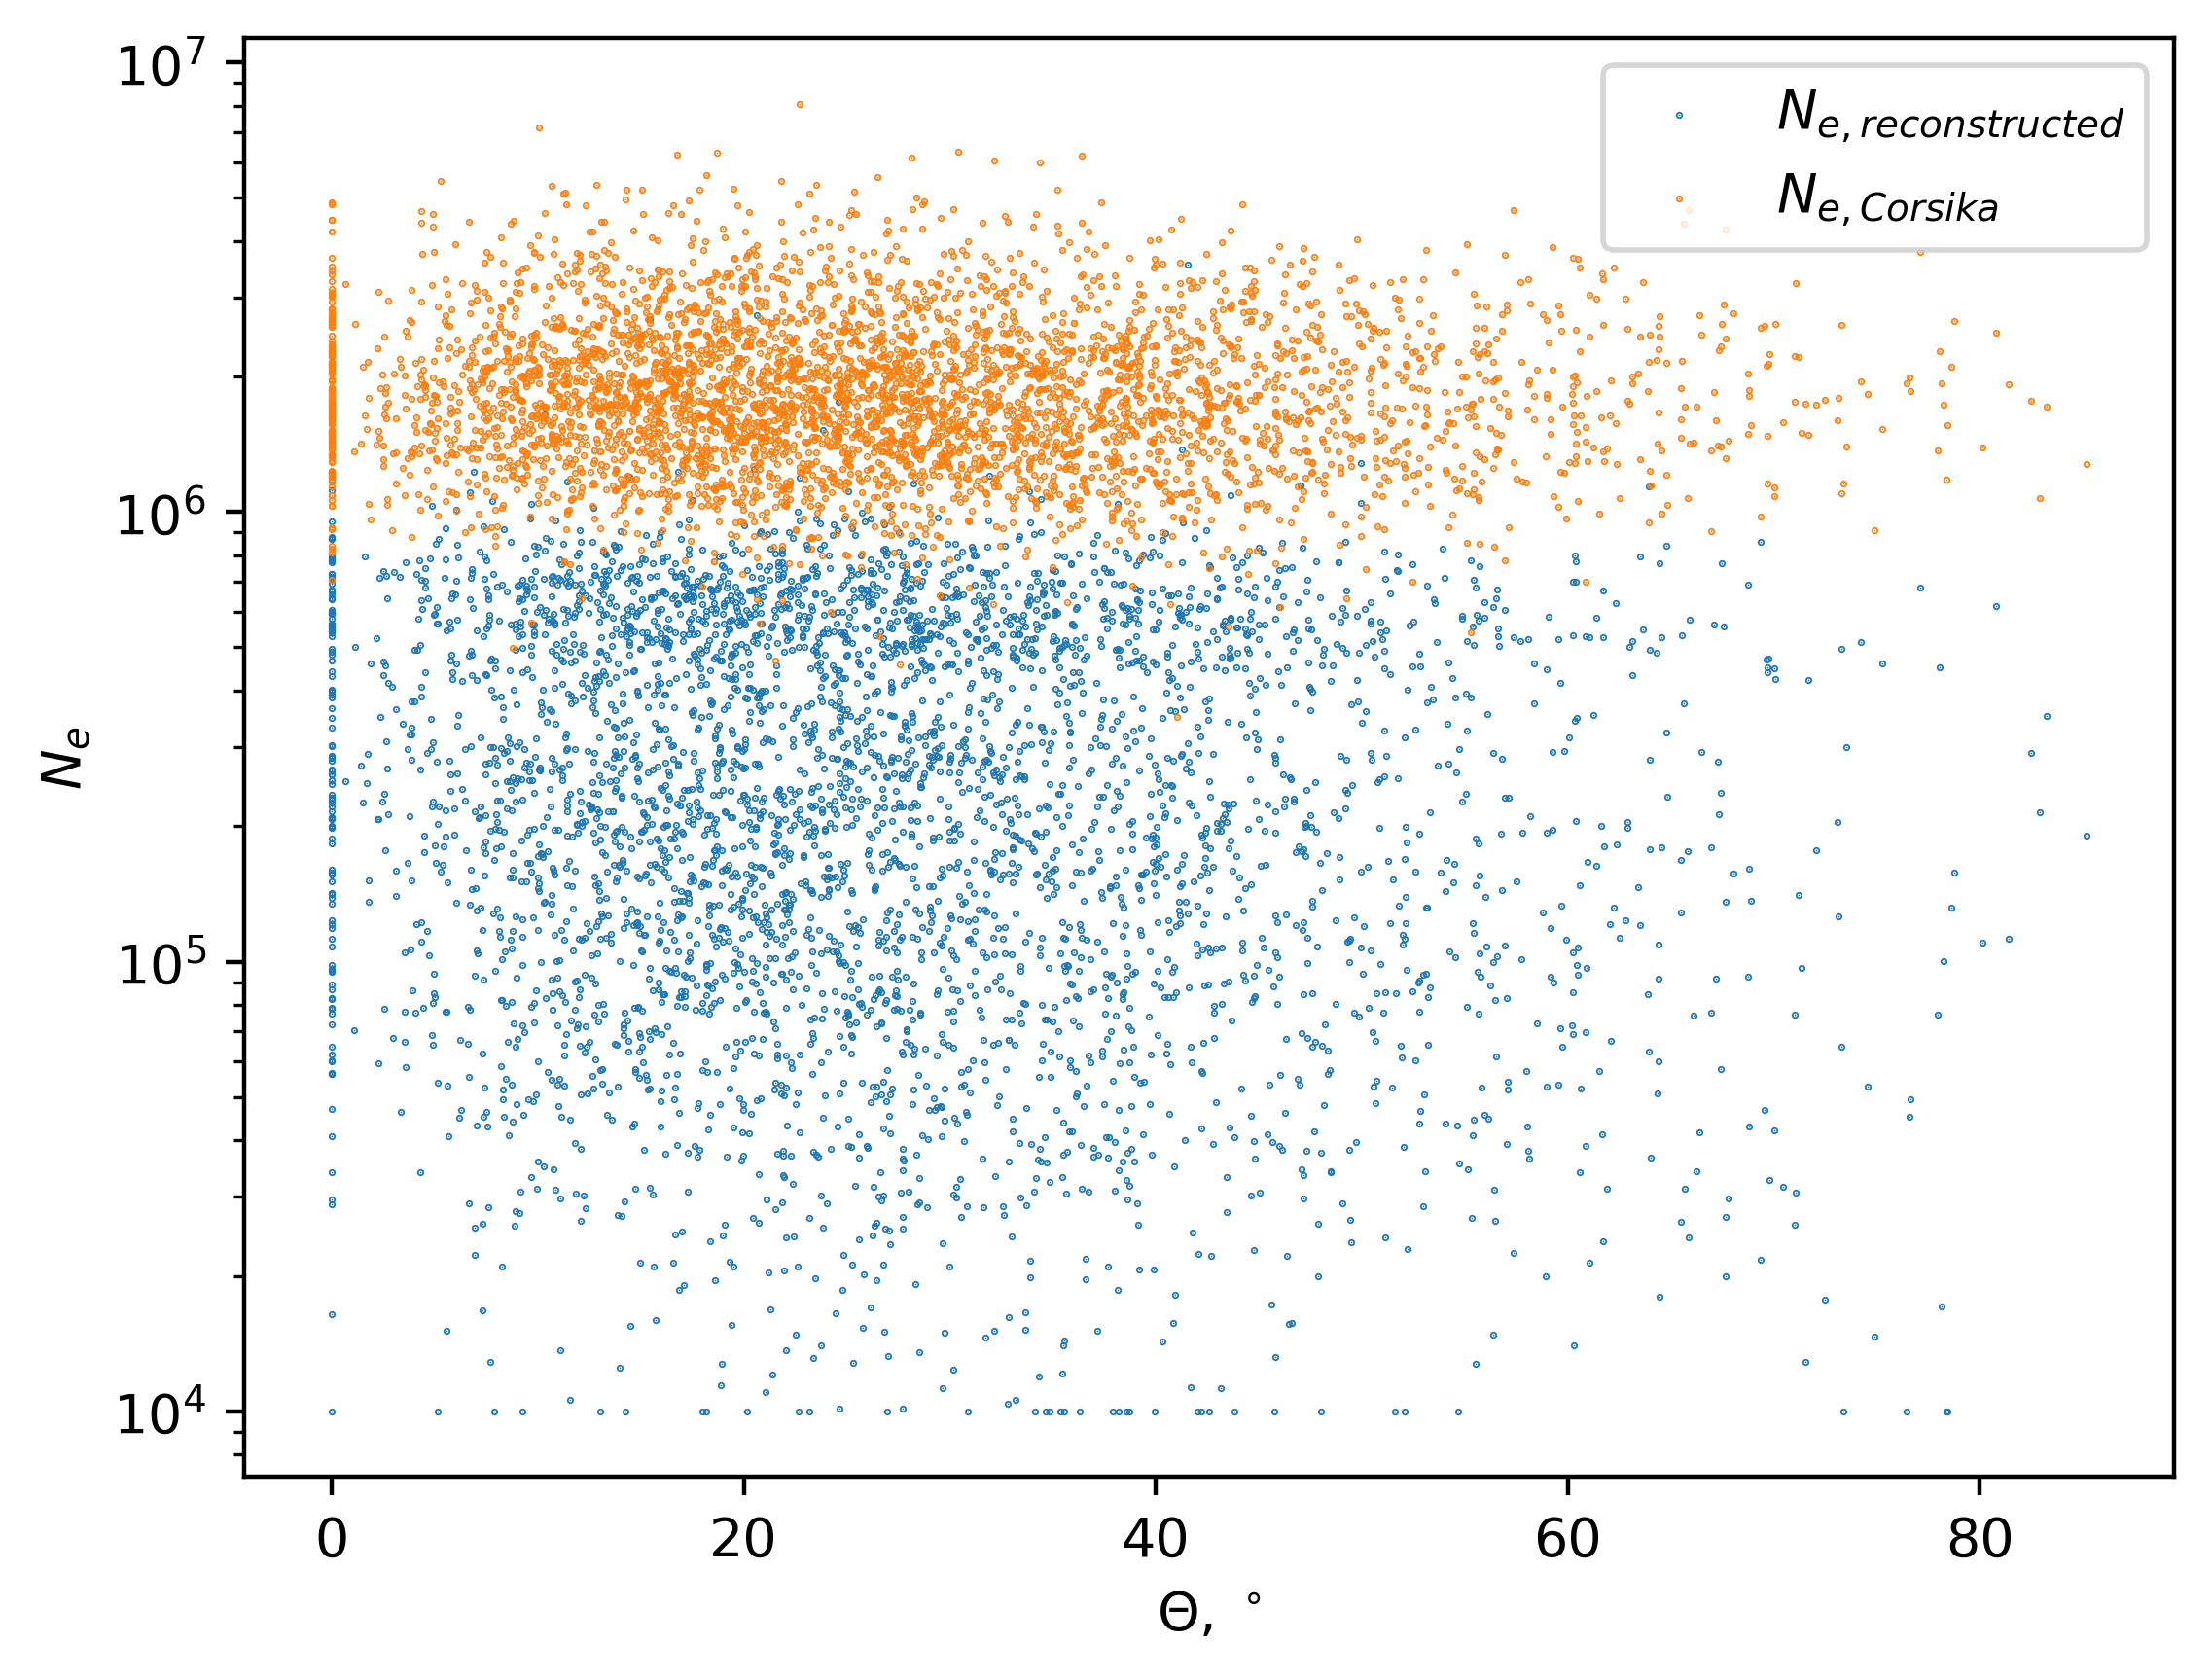

In [17]:
plt.scatter(np.degrees(theta), Ne, s=0.1, label='$N_{e,reconstructed}$')
plt.scatter(np.degrees(theta), Ne_true, s=0.1, label='$N_{e,Corsika}$')

plt.xlabel('$\Theta$, $^\circ$')
plt.ylabel('$N_{e}$')

plt.legend()

plt.yscale('log')
#plt.savefig('Ne(theta).png')

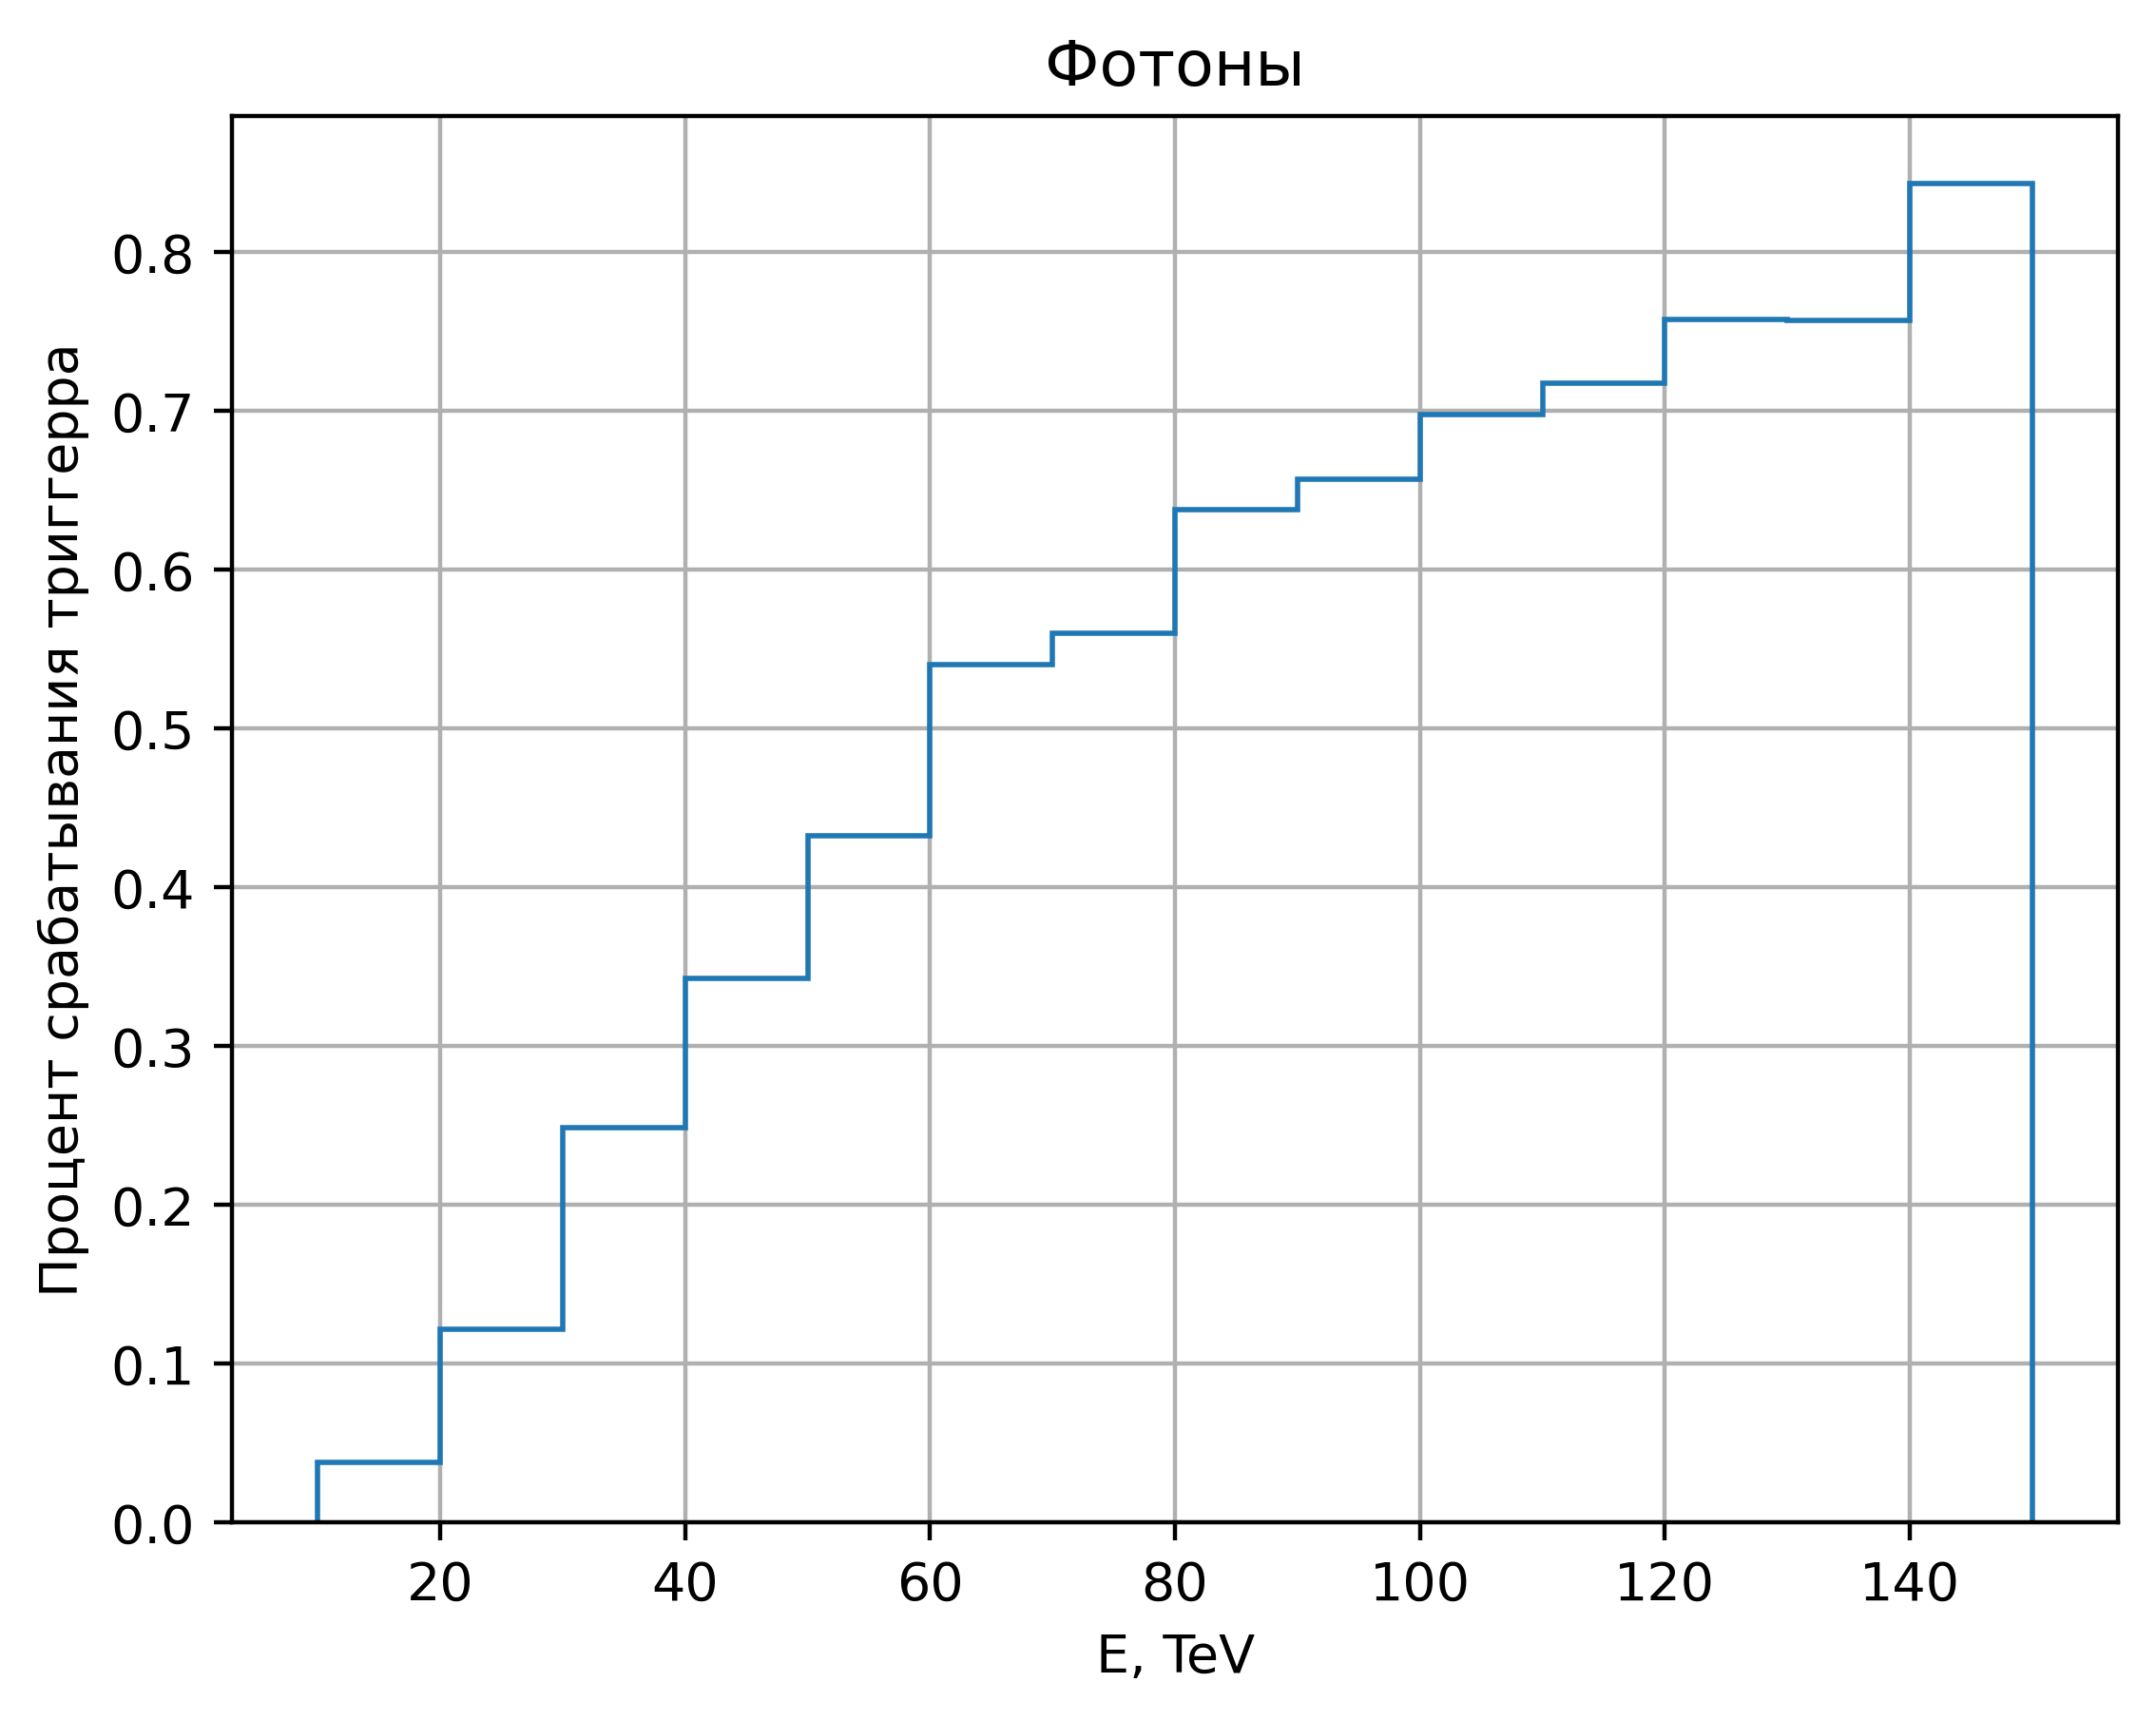

In [32]:
plt.hist(E, histtype='step', bins=14, weights = np.ones(len(E))/2000)

plt.xlabel('E, TeV')
plt.ylabel('Процент срабатывания триггерра')

plt.title('Фотоны')

plt.grid()

plt.savefig('photon_trigger_E.png')

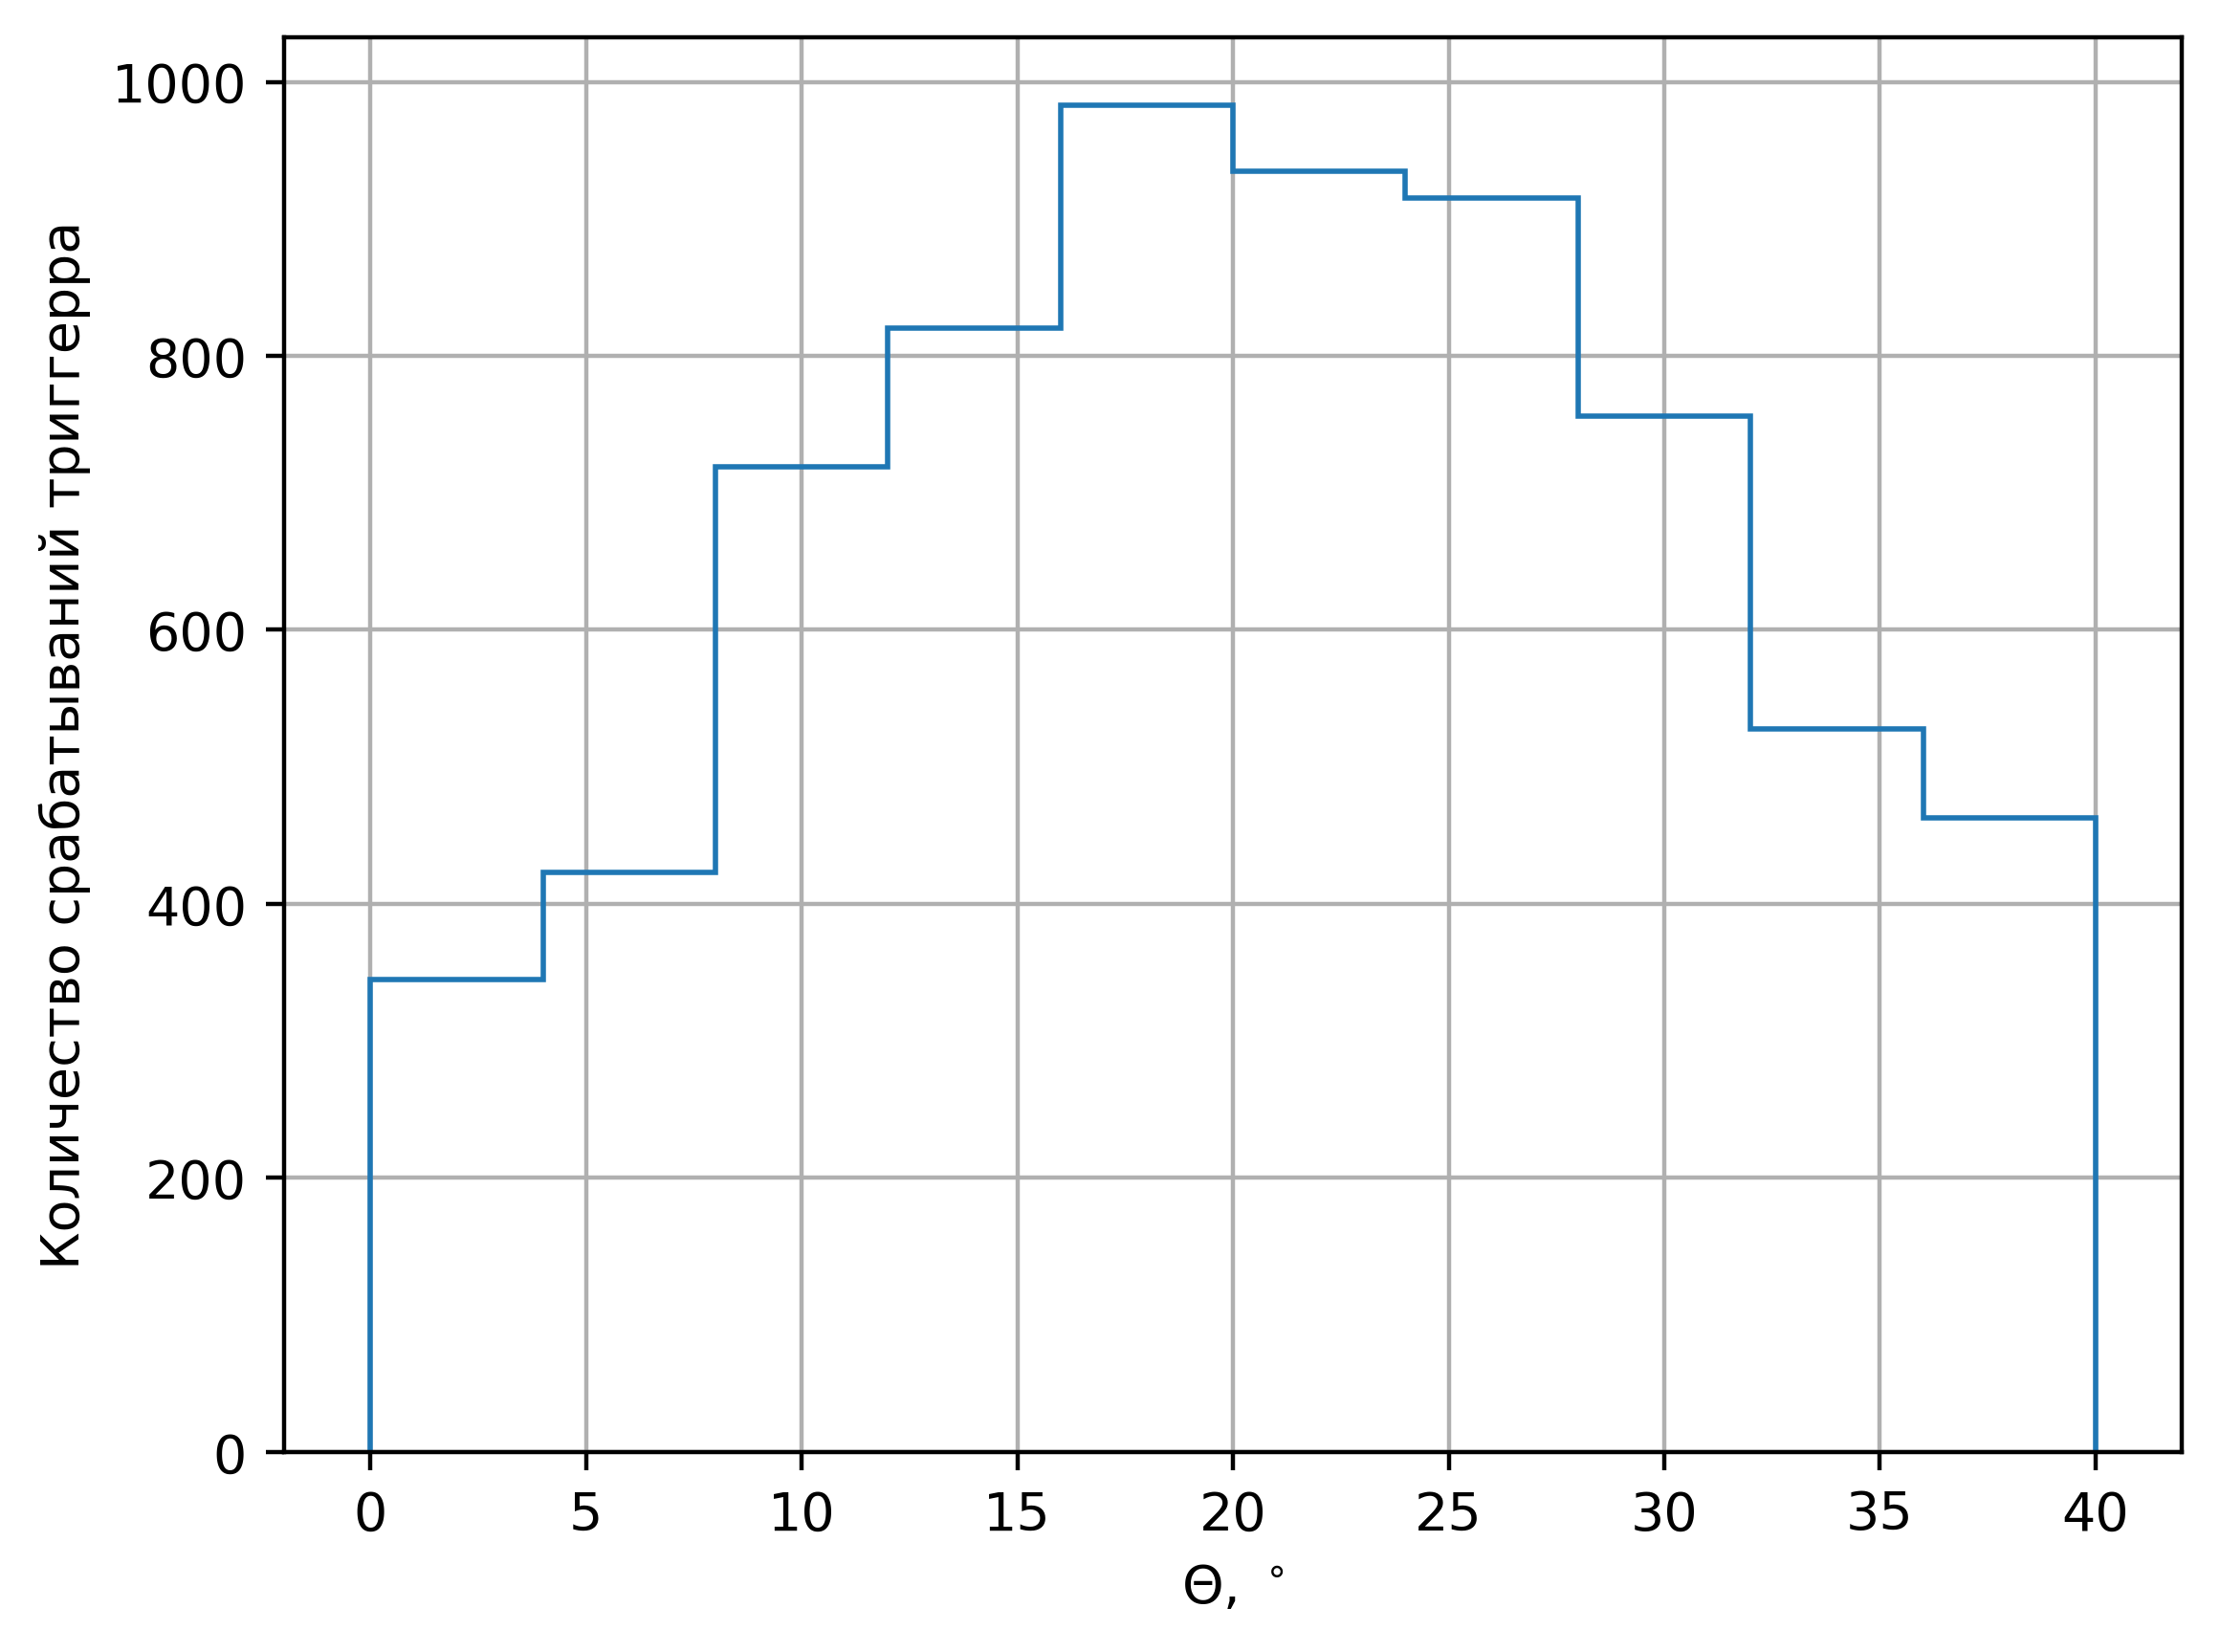

In [10]:
plt.hist(np.degrees(theta), histtype='step', bins=10, range=(0,40))

plt.xlabel('$\Theta$, $^\circ$')
plt.ylabel('Количество срабатываний триггерра')

plt.grid()

plt.savefig('Trigger_theta.png')

(array([[0., 1., 2., ..., 0., 0., 0.],
        [2., 3., 3., ..., 0., 0., 0.],
        [3., 1., 6., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [2., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]]),
 array([ 0.256803  ,  1.24856292,  2.24032285,  3.23208277,  4.2238427 ,
         5.21560262,  6.20736255,  7.19912247,  8.1908824 ,  9.18264232,
        10.17440225, 11.16616218, 12.1579221 , 13.14968202, 14.14144195,
        15.13320187, 16.1249618 , 17.11672173, 18.10848165, 19.10024158,
        20.0920015 , 21.08376143, 22.07552135, 23.06728128, 24.0590412 ,
        25.05080112, 26.04256105, 27.03432097, 28.0260809 , 29.01784083,
        30.00960075, 31.00136068, 31.9931206 , 32.98488052, 33.97664045,
        34.96840037, 35.9601603 , 36.95192022, 37.94368015, 38.93544007,
        39.9272    ]),
 array([ 0.        ,  2.18039684,  4.36079367,  6.54119051,  8.72158735,
        10.90198418, 13.08238102, 15.26277785, 17.44317469, 19.62357153

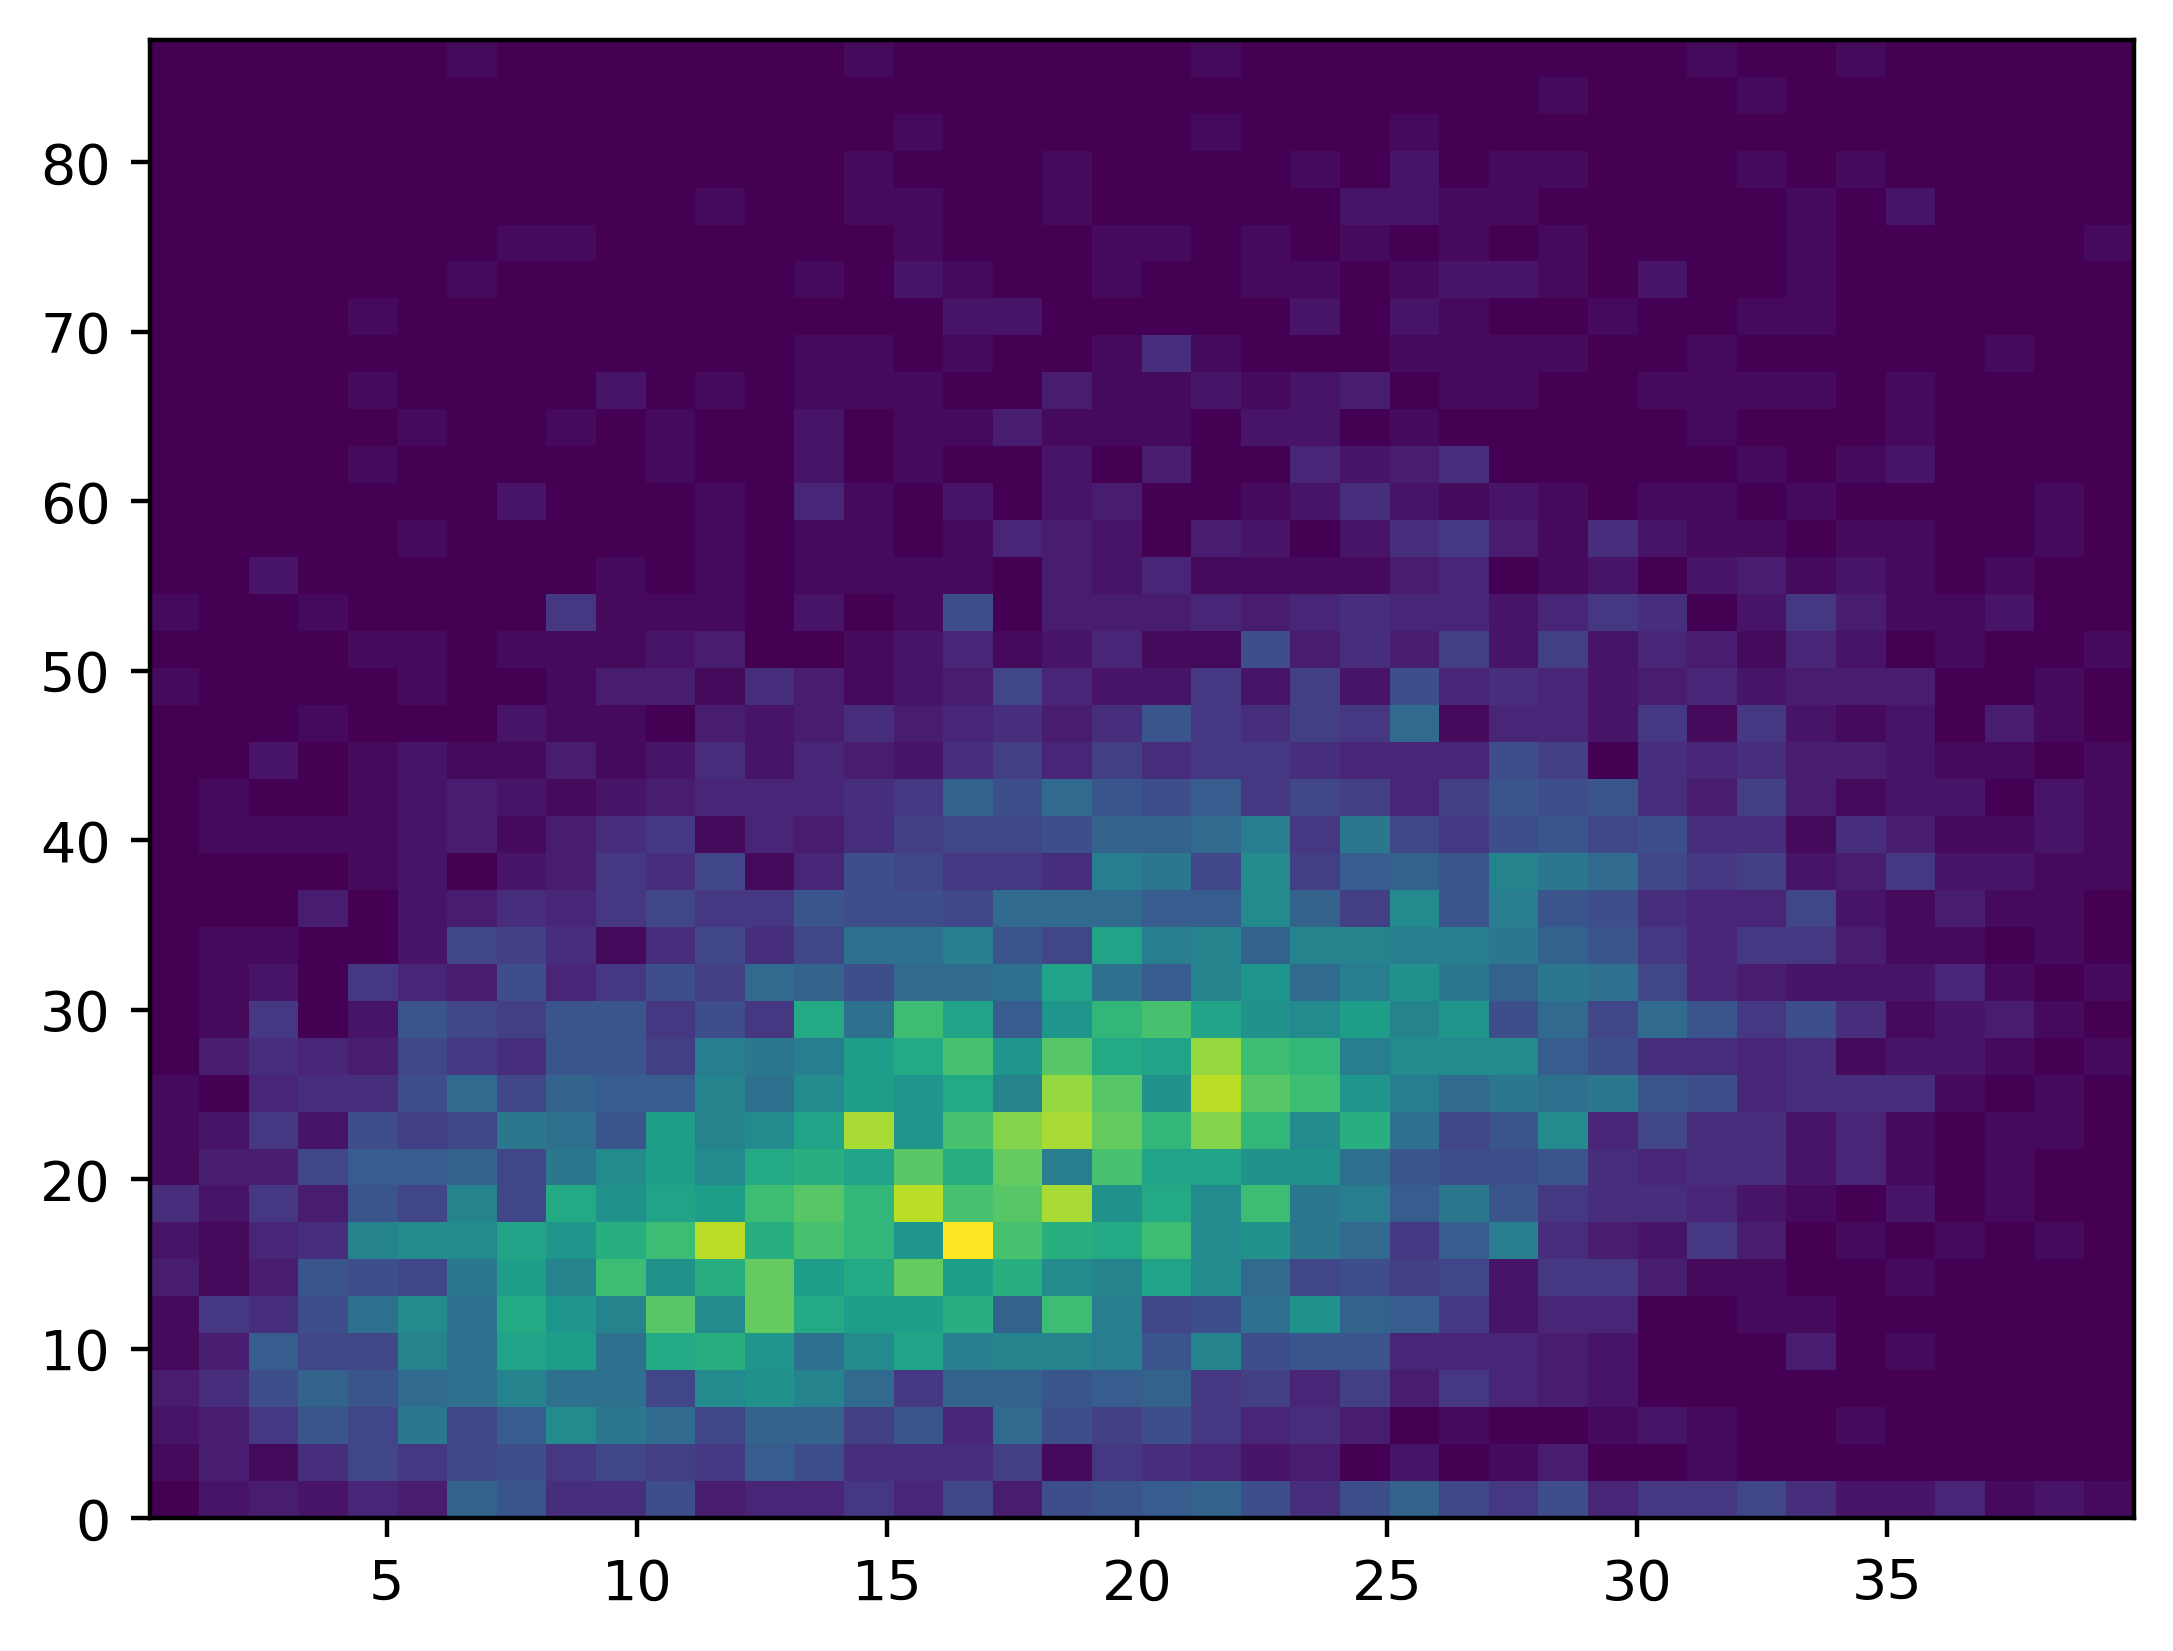

In [11]:
plt.hist2d(theta_true, np.degrees(theta), bins=40)

In [11]:
plt.hist2d(theta_true, theta_initial, bins=40)

NameError: name 'theta_initial' is not defined